# MedScan Alzheimer's — OASIS-1 Full Cohort Raw MRI Pipeline

This notebook is the local/Antigravity version of the Kaggle pipeline.

**Raw MRI root:** `C:\Projects\MedScan-Alzheimer's\Raw Data\disc1`

The pipeline is designed to avoid subject-level leakage. MRI records are matched to clinical labels first, subjects are split before preprocessing/slice extraction, and all scans belonging to a subject remain in the same split.

## 1. Install dependencies

Run this once in the Antigravity terminal if these packages are not already installed:

```bash
pip install numpy pandas matplotlib nibabel openpyxl scikit-learn jupyter
```

In [1]:
import os
import re
from collections import Counter

import numpy as np
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

print('Environment loaded successfully.')

Environment loaded successfully.


## 2. Configure local paths

In [2]:
# ============================================================
# PROJECT PATHS
# ============================================================

# Exact local path provided for OASIS-1 OASIS-1.
OASIS_ROOT = r"C:\Projects\MedScan-Alzheimer's\data\raw"

# Clinical Excel file is searched automatically inside Raw Data.
# If the Excel file is stored elsewhere, change CLINICAL_ROOT.
CLINICAL_ROOT = r"C:\Projects\MedScan-Alzheimer's\data\raw"

print('OASIS root:', OASIS_ROOT)
print('Clinical search root:', CLINICAL_ROOT)

assert os.path.exists(OASIS_ROOT), f'OASIS path not found: {OASIS_ROOT}'
assert os.path.exists(CLINICAL_ROOT), f'Clinical root not found: {CLINICAL_ROOT}'

print('\n✓ Paths exist.')

OASIS root: C:\Projects\MedScan-Alzheimer's\data\raw
Clinical search root: C:\Projects\MedScan-Alzheimer's\data\raw

✓ Paths exist.


## 2.5 Automate Archive Extraction

Automatically extract any `.tar.gz`, `.tar`, or `.zip` archives found in the `Raw Data` directory.

In [3]:
import tarfile
import zipfile

def extract_archives(data_dir):
    print(f'Scanning for archives in {data_dir}...')
    for file in os.listdir(data_dir):
        file_path = os.path.join(data_dir, file)
        if file.endswith('.tar.gz') or file.endswith('.tar'):
            folder_name = file.replace('.tar.gz', '').replace('.tar', '')
            extract_path = os.path.join(data_dir, folder_name)
            if not os.path.exists(extract_path):
                print(f'Extracting {file}...')
                with tarfile.open(file_path, 'r:*') as tar:
                    tar.extractall(path=extract_path)
                print(f'Extracted to {extract_path}')
            else:
                print(f'Folder {folder_name} already exists. Skipping {file}.')
        elif file.endswith('.zip'):
            folder_name = file.replace('.zip', '')
            extract_path = os.path.join(data_dir, folder_name)
            if not os.path.exists(extract_path):
                print(f'Extracting {file}...')
                with zipfile.ZipFile(file_path, 'r') as zip_ref:
                    zip_ref.extractall(extract_path)
                print(f'Extracted to {extract_path}')
            else:
                print(f'Folder {folder_name} already exists. Skipping {file}.')

extract_archives(OASIS_ROOT)


Scanning for archives in C:\Projects\MedScan-Alzheimer's\data\raw...


## 3. Discover the clinical Excel file

In [4]:
excel_files = []

for root, dirs, files in os.walk(CLINICAL_ROOT):
    for file in files:
        if file.lower().endswith(('.xlsx', '.xls')):
            excel_files.append(os.path.join(root, file))

print('Excel files found:')
for path in excel_files:
    print(path)

if len(excel_files) == 0:
    raise FileNotFoundError(
        'No Excel file was found under CLINICAL_ROOT. '
        'Set CLINICAL_ROOT to the folder containing the OASIS clinical XLSX.'
    )

# Prefer the OASIS cross-sectional clinical/demographic spreadsheet.
preferred = [
    p for p in excel_files
    if 'cross-sectional' in os.path.basename(p).lower()
    and 'reliability' not in os.path.basename(p).lower()
]

if len(preferred) == 1:
    CLINICAL_PATH = preferred[0]
elif len(excel_files) == 1:
    CLINICAL_PATH = excel_files[0]
else:
    raise RuntimeError(
        'Multiple Excel files were found. Set CLINICAL_PATH manually in this cell.'
    )

print('\nSelected clinical file:')
print(CLINICAL_PATH)

Excel files found:
C:\Projects\MedScan-Alzheimer's\data\raw\oasis_cross-sectional-5708aa0a98d82080 (1).xlsx

Selected clinical file:
C:\Projects\MedScan-Alzheimer's\data\raw\oasis_cross-sectional-5708aa0a98d82080 (1).xlsx


## 4. Load clinical data

In [5]:
clinical_df = pd.read_excel(CLINICAL_PATH)

print('Rows:', clinical_df.shape[0])
print('Columns:', clinical_df.shape[1])
print('\nColumns:')
print(clinical_df.columns.tolist())

display(clinical_df.head())

Rows: 436
Columns: 12

Columns:
['ID', 'M/F', 'Hand', 'Age', 'Educ', 'SES', 'MMSE', 'CDR', 'eTIV', 'nWBV', 'ASF', 'Delay']


,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0001_MR1,F,R,74,2.0,3.0,29.0,0.0,1344,0.743,1.306,NaN
1,OAS1_0002_MR1,F,R,55,4.0,1.0,29.0,0.0,1147,0.810,1.531,NaN
2,OAS1_0003_MR1,F,R,73,4.0,3.0,27.0,0.5,1454,0.708,1.207,NaN
3,OAS1_0004_MR1,M,R,28,NaN,NaN,NaN,NaN,1588,0.803,1.105,NaN
4,OAS1_0005_MR1,M,R,18,NaN,NaN,NaN,NaN,1737,0.848,1.010,NaN


In [6]:
print('Clinical subjects:', clinical_df['ID'].nunique())

print('\nCDR distribution across entire clinical dataset:')
print(clinical_df['CDR'].value_counts(dropna=False).sort_index())

Clinical subjects: 436

CDR distribution across entire clinical dataset:
CDR
0.0    135
0.5     70
1.0     28
2.0      2
NaN    201
Name: count, dtype: int64


## 5. Discover raw OASIS subjects and RAW folders

In [7]:
discovered_subjects = []

for root, dirs, files in os.walk(OASIS_ROOT):
    for directory in dirs:
        if re.fullmatch(r'OAS1_\d+_MR\d+', directory):
            discovered_subjects.append(os.path.join(root, directory))

discovered_subjects = sorted(set(discovered_subjects))

print('Subjects discovered:', len(discovered_subjects))
print('\nFirst 20 subjects:')
for subject in discovered_subjects[:20]:
    print(subject)

Subjects discovered: 436

First 20 subjects:
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0349_MR1
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0350_MR1
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0351_MR1
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0352_MR1
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0353_MR1
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0353_MR2
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0354_MR1
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0355_MR1
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0356_MR1
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0357_MR1
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0358_MR1
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0359_MR1
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0361_MR1
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0362_MR1
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0363_MR1
C:\Projects\MedScan-Alzhe

In [8]:
raw_folders = []

for root, dirs, files in os.walk(OASIS_ROOT):
    if os.path.basename(root).upper() == 'RAW':
        raw_folders.append(root)

raw_folders = sorted(raw_folders)

print('RAW folders found:', len(raw_folders))
print('\nFirst 20:')
for folder in raw_folders[:20]:
    print(folder)

RAW folders found: 437

First 20:
C:\Projects\MedScan-Alzheimer's\data\raw
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0349_MR1\RAW
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0350_MR1\RAW
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0351_MR1\RAW
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0352_MR1\RAW
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0353_MR1\RAW
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0353_MR2\RAW
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0354_MR1\RAW
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0355_MR1\RAW
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0356_MR1\RAW
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0357_MR1\RAW
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0358_MR1\RAW
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0359_MR1\RAW
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0361_MR1\RAW
C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0362_MR1\RAW
C

## 6. Build the raw MRI scan inventory

In [9]:
scan_records = []

for raw_folder in raw_folders:
    subject_folder = os.path.dirname(raw_folder)
    subject_id = os.path.basename(subject_folder)

    for file in os.listdir(raw_folder):
        if file.lower().endswith('.img'):
            img_path = os.path.join(raw_folder, file)
            hdr_file = os.path.splitext(file)[0] + '.hdr'
            hdr_path = os.path.join(raw_folder, hdr_file)

            scan_records.append({
                'subject_id': subject_id,
                'img_path': img_path,
                'hdr_path': hdr_path,
                'img_exists': os.path.exists(img_path),
                'hdr_exists': os.path.exists(hdr_path)
            })

scans_df = pd.DataFrame(scan_records)

print('Total scans discovered:', len(scans_df))
print('Unique subjects:', scans_df['subject_id'].nunique())

display(scans_df.head(10))

Total scans discovered: 1688
Unique subjects: 436


,subject_id,img_path,hdr_path,img_exists,hdr_exists
0,OAS1_0349_MR1,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,True,True
1,OAS1_0349_MR1,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,True,True
2,OAS1_0349_MR1,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,True,True
3,OAS1_0349_MR1,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,True,True
4,OAS1_0350_MR1,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,True,True
5,OAS1_0350_MR1,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,True,True
6,OAS1_0350_MR1,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,True,True
7,OAS1_0350_MR1,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,True,True
8,OAS1_0351_MR1,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,True,True
9,OAS1_0351_MR1,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,True,True


## 7. Verify IMG/HDR integrity

In [10]:
print('IMG files missing:')
print((~scans_df['img_exists']).sum())

print('\nHDR files missing:')
print((~scans_df['hdr_exists']).sum())

valid_records = scans_df['img_exists'] & scans_df['hdr_exists']
print('\nRecords with both IMG and HDR:')
print(valid_records.sum())

assert valid_records.all(), 'At least one scan is missing its IMG or HDR pair.'
print('\n✓ All discovered scan records have valid IMG + HDR pairs.')

IMG files missing:
0

HDR files missing:
0

Records with both IMG and HDR:
1688

✓ All discovered scan records have valid IMG + HDR pairs.


## 8. Join MRI records with clinical labels

In [11]:
dataset_df = scans_df.merge(
    clinical_df,
    left_on='subject_id',
    right_on='ID',
    how='left',
    validate='many_to_one'
)

print('Joined rows:', len(dataset_df))
print('Joined columns:', len(dataset_df.columns))

display(dataset_df.head())

Joined rows: 1688
Joined columns: 17


,subject_id,img_path,hdr_path,img_exists,hdr_exists,ID,M/F,Hand,Age,Educ,SES,MMSE,CDR,eTIV,nWBV,ASF,Delay
0,OAS1_0349_MR1,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,True,True,OAS1_0349_MR1,F,R,43,NaN,NaN,NaN,NaN,1227,0.858,1.430,NaN
1,OAS1_0349_MR1,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,True,True,OAS1_0349_MR1,F,R,43,NaN,NaN,NaN,NaN,1227,0.858,1.430,NaN
2,OAS1_0349_MR1,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,True,True,OAS1_0349_MR1,F,R,43,NaN,NaN,NaN,NaN,1227,0.858,1.430,NaN
3,OAS1_0349_MR1,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,True,True,OAS1_0349_MR1,F,R,43,NaN,NaN,NaN,NaN,1227,0.858,1.430,NaN
4,OAS1_0350_MR1,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,C:\Projects\MedScan-Alzheimer's\data\raw\disc1...,True,True,OAS1_0350_MR1,M,R,21,NaN,NaN,NaN,NaN,1577,0.869,1.113,NaN


In [12]:
subject_labels = dataset_df[['subject_id', 'CDR']].drop_duplicates()

print('Unique MRI subjects:', len(subject_labels))
print('Subjects with CDR:', subject_labels['CDR'].notna().sum())
print('Subjects without CDR:', subject_labels['CDR'].isna().sum())

labeled_summary = dataset_df[dataset_df['CDR'].notna()][['subject_id', 'CDR']].drop_duplicates()

print('\nLabeled OASIS-1 subjects:', len(labeled_summary))
print('\nCDR distribution in OASIS-1:')
print(labeled_summary['CDR'].value_counts().sort_index())

Unique MRI subjects: 436
Subjects with CDR: 235
Subjects without CDR: 201

Labeled OASIS-1 subjects: 235

CDR distribution in OASIS-1:
CDR
0.0    135
0.5     70
1.0     28
2.0      2
Name: count, dtype: int64


## 9. Create the labeled OASIS-1 dataset

For the current pipeline test, subjects without a valid CDR are excluded from supervised classification. Missing CDR is **not** treated as CDR 0.

In [13]:
labeled_df = dataset_df[dataset_df['CDR'].notna()].copy()

# Merge CDR 2.0 (Moderate) into CDR 1.0 (Mild) due to low sample size (n=2)
labeled_df.loc[labeled_df['CDR'] == 2.0, 'CDR'] = 1.0

print('Total labeled MRI records:', len(labeled_df))
print('Unique labeled subjects:', labeled_df['subject_id'].nunique())

print('\nSubject-level CDR distribution:')
print(
    labeled_df[['subject_id', 'CDR']]
    .drop_duplicates()['CDR']
    .value_counts()
    .sort_index()
)

Total labeled MRI records: 913
Unique labeled subjects: 235

Subject-level CDR distribution:
CDR
0.0    135
0.5     70
1.0     30
Name: count, dtype: int64


In [14]:
scan_counts = (
    labeled_df
    .groupby('subject_id')
    .size()
    .sort_values(ascending=False)
)

print(scan_counts)
print('\nTotal labeled MRI records:', scan_counts.sum())

subject_id
OAS1_0254_MR1    6
OAS1_0401_MR1    5
OAS1_0001_MR1    4
OAS1_0010_MR1    4
OAS1_0011_MR1    4
                ..
OAS1_0451_MR1    3
OAS1_0453_MR1    3
OAS1_0454_MR1    3
OAS1_0455_MR1    3
OAS1_0457_MR1    3
Length: 235, dtype: int64

Total labeled MRI records: 913


## 10. Create subject-level metadata

In [15]:
subject_df = (
    labeled_df[['subject_id', 'CDR']]
    .drop_duplicates()
    .sort_values('subject_id')
    .reset_index(drop=True)
)

print('Total unique subjects:', len(subject_df))
print('\nSubject-level class distribution:')
print(subject_df['CDR'].value_counts().sort_index())

display(subject_df)

Total unique subjects: 235

Subject-level class distribution:
CDR
0.0    135
0.5     70
1.0     30
Name: count, dtype: int64


,subject_id,CDR
0,OAS1_0001_MR1,0.0
1,OAS1_0002_MR1,0.0
2,OAS1_0003_MR1,0.5
3,OAS1_0010_MR1,0.0
4,OAS1_0011_MR1,0.0
...,...,...
230,OAS1_0453_MR1,0.5
231,OAS1_0454_MR1,0.5
232,OAS1_0455_MR1,0.0
233,OAS1_0456_MR1,0.0


## 11. Subject-level train/test split

This uses the full OASIS-1 cohort across all 12 discs with 3 CDR classes (0.0, 0.5, 1.0).

The split is performed at subject level before slice extraction or preprocessing.

In [16]:
train_subjects, test_subjects = train_test_split(
    subject_df,
    test_size=0.20,
    random_state=42,
    stratify=subject_df['CDR']
)

train_subjects = train_subjects.reset_index(drop=True)
test_subjects = test_subjects.reset_index(drop=True)

print('Training subjects:', len(train_subjects))
print('Testing subjects:', len(test_subjects))

print('\nTraining class distribution:')
print(train_subjects['CDR'].value_counts().sort_index())

print('\nTesting class distribution:')
print(test_subjects['CDR'].value_counts().sort_index())

Training subjects: 188
Testing subjects: 47

Training class distribution:
CDR
0.0    108
0.5     56
1.0     24
Name: count, dtype: int64

Testing class distribution:
CDR
0.0    27
0.5    14
1.0     6
Name: count, dtype: int64


## 12. Attach split labels to every MRI record

In [17]:
train_subject_ids = set(train_subjects['subject_id'])
test_subject_ids = set(test_subjects['subject_id'])

labeled_df['split'] = labeled_df['subject_id'].apply(
    lambda x: 'train' if x in train_subject_ids
    else 'test' if x in test_subject_ids
    else 'unknown'
)

print('MRI records by split:')
print(labeled_df['split'].value_counts())

print('\nUnique subjects by split:')
print(labeled_df.groupby('split')['subject_id'].nunique())

assert (labeled_df['split'] != 'unknown').all(), 'Some records were not assigned to a split.'

MRI records by split:
split
train    734
test     179
Name: count, dtype: int64

Unique subjects by split:
split
test      47
train    188
Name: subject_id, dtype: int64


## 13. Critical leakage check

In [18]:
train_ids = set(
    labeled_df.loc[labeled_df['split'] == 'train', 'subject_id']
)

test_ids = set(
    labeled_df.loc[labeled_df['split'] == 'test', 'subject_id']
)

overlap = train_ids.intersection(test_ids)

print('Training subjects:', len(train_ids))
print('Testing subjects:', len(test_ids))
print('Subject overlap:', len(overlap))

if overlap:
    print('\n❌ LEAKAGE DETECTED:')
    print(overlap)
    raise AssertionError('Subject-level leakage detected.')
else:
    print('\n✅ No subject-level leakage.')

Training subjects: 188
Testing subjects: 47
Subject overlap: 0

✅ No subject-level leakage.


## 14. Inspect one raw MRI volume

In [19]:
import gc

# FIXED: `get_fdata()` defaults to float64. For a (256, 256, 128, 1)
# volume that's 64MB instead of 32MB for the same data -- and the
# traceback shows the very first volume in the notebook failing to
# allocate that 64MB. Passing dtype=np.float32 explicitly (same as
# the preprocessing notebook does) halves the memory this call needs.
# This alone won't help if the machine is already almost entirely out
# of free RAM (see the diagnostic below), but it removes an easy,
# unnecessary 2x overhead on every volume you load in this notebook.

# Quick free-memory diagnostic -- helps distinguish "the code was
# wasteful" from "the machine genuinely has very little RAM available"
# for MemoryErrors like this one.
try:
    import psutil
    mem = psutil.virtual_memory()
    print(f"System RAM: {mem.total / 1e9:.1f} GB total, "
          f"{mem.available / 1e9:.2f} GB available "
          f"({mem.percent}% used)")
    if mem.available < 500e6:
        print("⚠️  Less than 500MB available -- close other applications "
              "or restart the kernel if you keep hitting MemoryError.")
except ImportError:
    print("(install `psutil` for a free-memory diagnostic: pip install psutil)")

first_scan = labeled_df.iloc[0]
img_path = first_scan['img_path']

nii = nib.load(img_path)
volume = np.squeeze(nii.get_fdata(dtype=np.float32))  # FIXED: was get_fdata() -> float64

print('Subject:', first_scan['subject_id'])
print('IMG path:', img_path)
print('Original NIfTI/Analyze shape:', nii.shape)
print('Squeezed volume shape:', volume.shape)
print('Loaded array dtype:', volume.dtype, '(raw on-disk dtype:', nii.get_data_dtype(), ')')
print('Orientation:', nib.aff2axcodes(nii.affine))
print('Voxel spacing:', nii.header.get_zooms()[:3])

System RAM: 16.5 GB total, 5.45 GB available (66.9% used)
Subject: OAS1_0351_MR1
IMG path: C:\Projects\MedScan-Alzheimer's\data\raw\disc10\OAS1_0351_MR1\RAW\OAS1_0351_MR1_mpr-1_anon.img
Original NIfTI/Analyze shape: (256, 256, 128, 1)
Squeezed volume shape: (256, 256, 128)
Loaded array dtype: float32 (raw on-disk dtype: >i2 )
Orientation: ('L', 'A', 'S')
Voxel spacing: (np.float32(1.0), np.float32(1.0), np.float32(1.25))


## 15. Raw intensity statistics

In [20]:
print('Intensity statistics:')
print('Min:', np.min(volume))
print('Max:', np.max(volume))
print('Mean:', np.mean(volume))
print('Median:', np.median(volume))
print('Std:', np.std(volume))

print('\nPercentiles:')
for p in [1, 5, 25, 50, 75, 95, 99]:
    print(f'{p}th percentile:', np.percentile(volume, p))

Intensity statistics:
Min: 0.0
Max: 4095.0
Mean: 384.96622
Median: 0.0
Std: 635.9111

Percentiles:
1th percentile: 0.0
5th percentile: 0.0
25th percentile: 0.0
50th percentile: 0.0
75th percentile: 632.0
95th percentile: 1692.0
99th percentile: 2749.0


## 16. Check dimensions, voxel spacing, and orientation across all labeled scans

Do this before designing the 3D-to-2D preprocessing pipeline.

In [21]:
shape_counts = Counter()
spacing_counts = Counter()
orientation_counts = Counter()

for _, row in labeled_df.iterrows():
    nii = nib.load(row['img_path'])

    shape_counts[nii.shape] += 1
    spacing = tuple(round(float(x), 4) for x in nii.header.get_zooms()[:3])
    spacing_counts[spacing] += 1
    orientation = ''.join(nib.aff2axcodes(nii.affine))
    orientation_counts[orientation] += 1

print('Unique MRI shapes:')
for shape, count in shape_counts.items():
    print(f'{shape} → {count} scans')

print('\nUnique voxel spacings:')
for spacing, count in spacing_counts.items():
    print(f'{spacing} → {count} scans')

print('\nMRI orientations:')
for orientation, count in orientation_counts.items():
    print(f'{orientation} → {count} scans')

Unique MRI shapes:
(256, 256, 128, 1) → 913 scans

Unique voxel spacings:
(1.0, 1.0, 1.25) → 913 scans

MRI orientations:
LAS → 913 scans


## 17. Canonical orientation check

The raw scans are currently LAS. Before extracting anatomical 2D slices, convert the volume to a consistent canonical RAS orientation.

In [22]:
# FIXED: same float64 -> float32 issue as the previous cell.
# Also frees `volume` (the non-canonical copy from two cells ago,
# ~32MB) before allocating `volume_ras`, since nothing later in the
# notebook needs the non-canonical array -- no reason to hold both
# full volumes in memory at once.
del volume
gc.collect()

nii_ras = nib.as_closest_canonical(nii)
volume_ras = np.squeeze(nii_ras.get_fdata(dtype=np.float32))  # FIXED: was get_fdata() -> float64

print('Original orientation:', nib.aff2axcodes(nii.affine))
print('Canonical orientation:', nib.aff2axcodes(nii_ras.affine))
print('Original shape:', nii.shape)
print('Canonical shape:', volume_ras.shape)

Original orientation: ('L', 'A', 'S')
Canonical orientation: ('R', 'A', 'S')
Original shape: (256, 256, 128, 1)
Canonical shape: (256, 256, 128)


## 18. Visualize canonical axial slices

Do not save these as JPG/PNG for training yet. This is only a visual inspection step. The model pipeline will later operate on arrays/tensors.

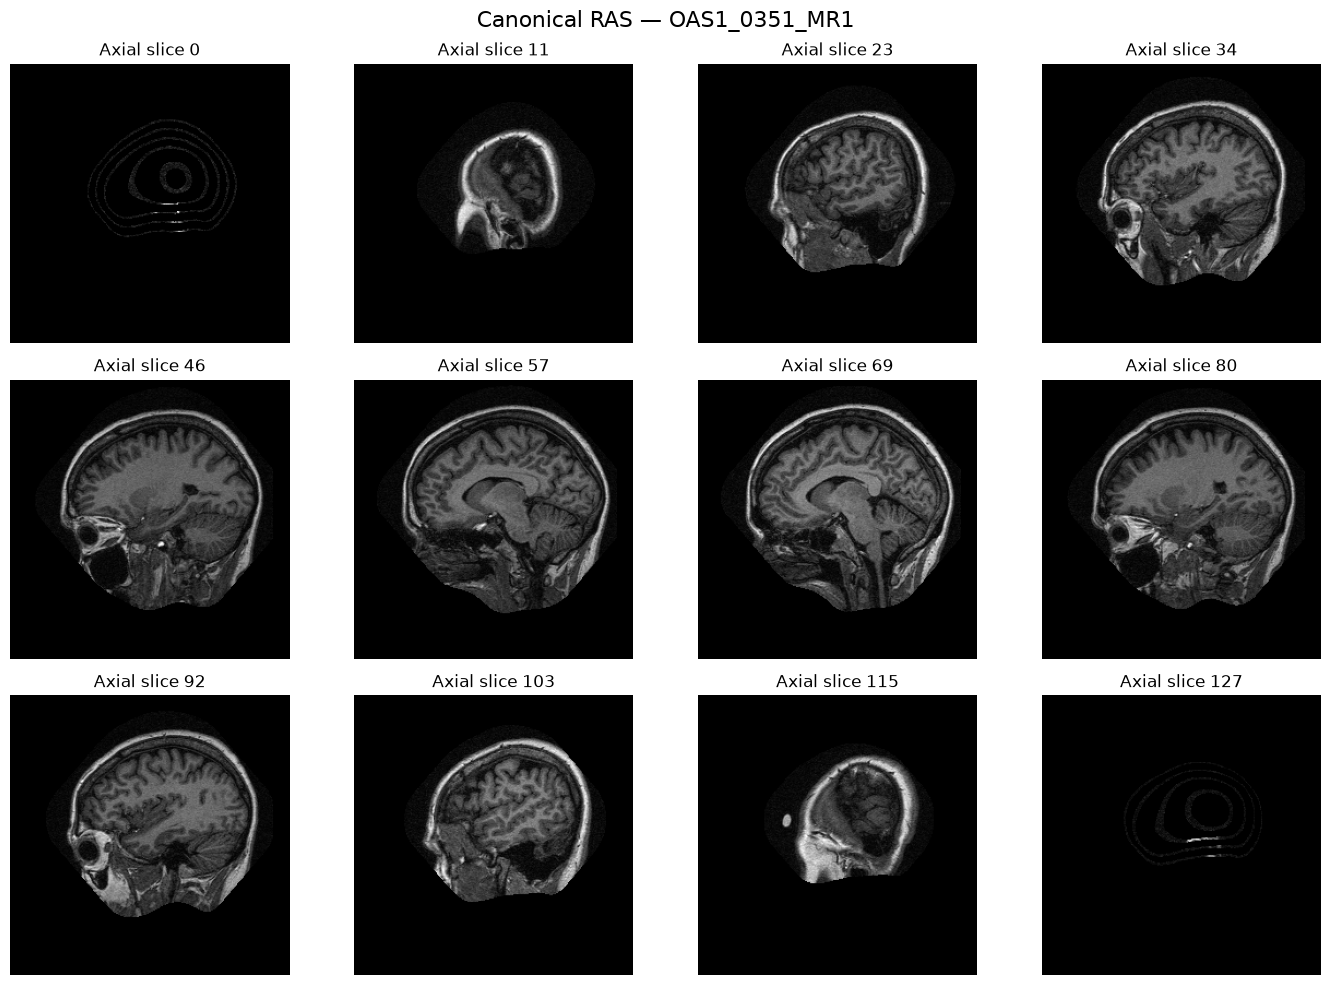

In [23]:
slice_indices = np.linspace(
    0,
    volume_ras.shape[2] - 1,
    12,
    dtype=int
)

fig, axes = plt.subplots(3, 4, figsize=(14, 10))

for ax, idx in zip(axes.ravel(), slice_indices):
    ax.imshow(
        volume_ras[:, :, idx].T,
        cmap='gray',
        origin='lower'
    )
    ax.set_title(f'Axial slice {idx}')
    ax.axis('off')

plt.suptitle(
    f'Canonical RAS — {first_scan["subject_id"]}',
    fontsize=16
)
plt.tight_layout()
plt.show()

## Next stage

The next stage should be designed explicitly for a **2D CNN**:

1. Canonicalize each volume to RAS.
2. Define a reproducible axial slice-selection rule.
3. Apply intensity normalization without leaking test information.
4. Resize selected slices to the CNN input size (for example 224×224).
5. Apply augmentation to training data only.
6. Train the 2D CNN.
7. Aggregate slice predictions back to the **subject level**, because CDR is a subject-level label.

**Do not randomly split individual slices.** The subject-level split above must remain fixed.